# CityGo Ride-Sharing Data Analysis

## Project Overview
Urban mobility is changing rapidly, and ride-sharing apps have become an integral part of daily commuting. CityGo is a rising ride-sharing platform that connects riders with drivers through a mobile app. Our task is to analyze the dataset to understand user behavior, driver performance, and overall demand.

In [1]:
#importing Libraries/Packages

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.style as style
%matplotlib inline

In [2]:
#iporting data

citygo_data = pd.read_csv('citygo_trips.csv')

In [3]:
#sanity checks

citygo_data.head()

,trip_id,rider_id,driver_id,vehicle_type,trip_fare,day_type,rating,wait_time,trip_duration
0,100000,1352,5050,Shared,12.20,Weekday,4,12,48
1,100001,1012,5069,Shared,64.88,Weekend,5,8,37
2,100002,1338,5024,Economy,32.61,Weekday,2,9,69
3,100003,1327,5075,Economy,33.57,Weekday,Not given,18,24
4,100004,1064,5042,Economy,27.86,Weekend,5,20,49


In [4]:
citygo_data.tail()

,trip_id,rider_id,driver_id,vehicle_type,trip_fare,day_type,rating,wait_time,trip_duration
2495,102495,1391,5029,SUV,42.61,Weekday,Not given,18,71
2496,102496,1295,5091,Premium,14.79,Weekday,5,16,49
2497,102497,1025,5066,Premium,16.82,Weekend,4,22,50
2498,102498,1028,5042,Economy,31.16,Weekday,3,14,23
2499,102499,1055,5007,Economy,39.18,Weekend,2,19,50


In [5]:
citygo_data.shape

(2500, 9)

In [6]:
citygo_data.info

<bound method DataFrame.info of       trip_id  rider_id  driver_id vehicle_type  trip_fare day_type  \
0      100000      1352       5050       Shared      12.20  Weekday   
1      100001      1012       5069       Shared      64.88  Weekend   
2      100002      1338       5024      Economy      32.61  Weekday   
3      100003      1327       5075      Economy      33.57  Weekday   
4      100004      1064       5042      Economy      27.86  Weekend   
...       ...       ...        ...          ...        ...      ...   
2495   102495      1391       5029          SUV      42.61  Weekday   
2496   102496      1295       5091      Premium      14.79  Weekday   
2497   102497      1025       5066      Premium      16.82  Weekend   
2498   102498      1028       5042      Economy      31.16  Weekday   
2499   102499      1055       5007      Economy      39.18  Weekend   

         rating  wait_time  trip_duration  
0             4         12             48  
1             5          8 

In [7]:
citygo_data.dtypes

trip_id            int64
rider_id           int64
driver_id          int64
vehicle_type         str
trip_fare        float64
day_type             str
rating               str
wait_time          int64
trip_duration      int64
dtype: object

In [8]:
citygo_data.describe()

,trip_id,rider_id,driver_id,trip_fare,wait_time,trip_duration
count,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,101249.50000,1255.415600,5049.634000,35.634868,13.724400,41.475600
std,721.83216,145.084153,28.907478,16.574432,6.342786,18.681911
min,100000.00000,1001.000000,5001.000000,7.060000,3.000000,10.000000
25%,100624.75000,1127.750000,5024.000000,21.477500,8.000000,25.000000
50%,101249.50000,1262.000000,5050.000000,35.325000,14.000000,41.000000
75%,101874.25000,1384.000000,5074.000000,49.865000,19.000000,58.000000
max,102499.00000,1499.000000,5099.000000,64.970000,24.000000,74.000000


In [9]:
citygo_data.describe(include = "object")

C:\Users\HP\AppData\Local\Temp\ipykernel_11392\11712645.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  citygo_data.describe(include = "object")


,vehicle_type,day_type,rating
count,2500,2500,2500
unique,4,2,6
top,Economy,Weekday,5
freq,1387,1799,881


In [10]:
citygo_data.isna().sum()

trip_id          0
rider_id         0
driver_id        0
vehicle_type     0
trip_fare        0
day_type         0
rating           0
wait_time        0
trip_duration    0
dtype: int64

---

## Exploratory Data Analysis (EDA)

### Question 1: How many trips are not rated?

In [11]:
for columns in citygo_data.columns:
    print(columns)

trip_id
rider_id
driver_id
vehicle_type
trip_fare
day_type
rating
wait_time
trip_duration


In [12]:
citygo_data.duplicated().sum()

np.int64(0)

In [13]:
#trips rated
citygo_data['rating']

0               4
1               5
2               2
3       Not given
4               5
          ...    
2495    Not given
2496            5
2497            4
2498            3
2499            2
Name: rating, Length: 2500, dtype: str

Total Trips: 2500
Unrated Trips: 453
Percentage of Unrated Trips: 18.12%


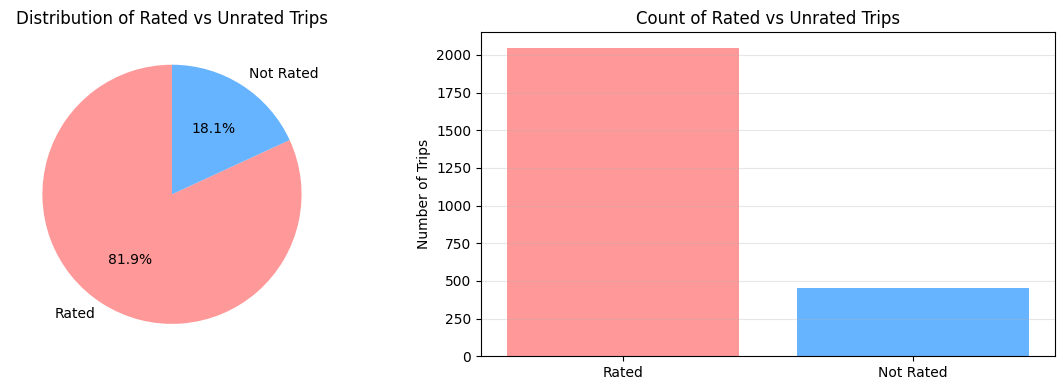

In [14]:
#trips not rated - Comprehensive Analysis
unrated_count = citygo_data['rating'].isin(['Not given']).sum()
total_trips = len(citygo_data)
unrated_percentage = (unrated_count / total_trips) * 100

print(f"Total Trips: {total_trips}")
print(f"Unrated Trips: {unrated_count}")
print(f"Percentage of Unrated Trips: {unrated_percentage:.2f}%")

# Visualize rated vs unrated trips
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie Chart
rating_status = citygo_data['rating'].apply(lambda x: 'Not Rated' if x == 'Not given' else 'Rated')
rating_counts = rating_status.value_counts()
colors = ['#ff9999', '#66b3ff']
axes[0].pie(rating_counts, labels=rating_counts.index, autopct='%1.1f%%', colors=colors, startangle=90)
axes[0].set_title('Distribution of Rated vs Unrated Trips')

# Bar Chart
axes[1].bar(rating_counts.index, rating_counts.values, color=colors)
axes[1].set_ylabel('Number of Trips')
axes[1].set_title('Count of Rated vs Unrated Trips')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
#citygo_data['rating'].value_counts().head(1)

In [16]:
citygo_data.head(5)

,trip_id,rider_id,driver_id,vehicle_type,trip_fare,day_type,rating,wait_time,trip_duration
0,100000,1352,5050,Shared,12.20,Weekday,4,12,48
1,100001,1012,5069,Shared,64.88,Weekend,5,8,37
2,100002,1338,5024,Economy,32.61,Weekday,2,9,69
3,100003,1327,5075,Economy,33.57,Weekday,Not given,18,24
4,100004,1064,5042,Economy,27.86,Weekend,5,20,49


### Question 2: Explore all the variables and provide observations on their distributions

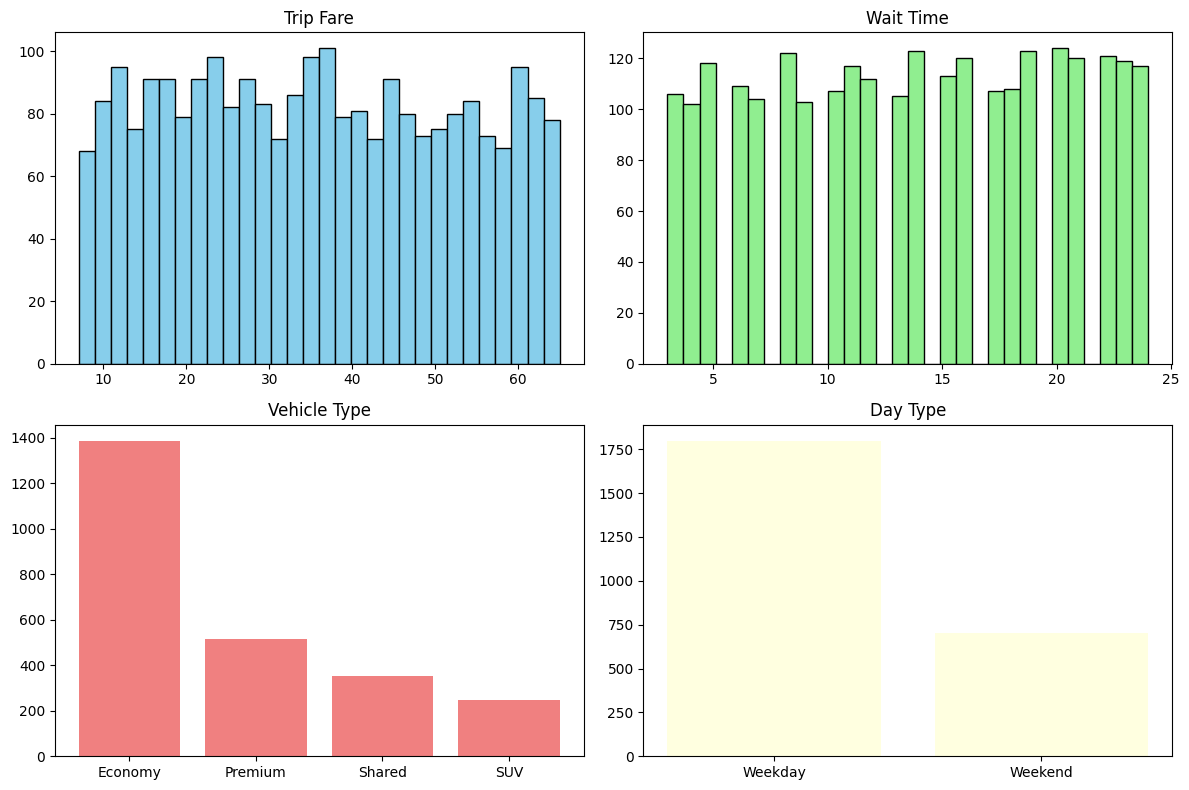

Mean Fare: $35.63 | Mean Duration: 41.5 min


In [17]:
## Numerical & Categorical Variables
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].hist(citygo_data['trip_fare'], bins=30, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Trip Fare')
axes[0, 1].hist(citygo_data['wait_time'], bins=30, color='lightgreen', edgecolor='black')
axes[0, 1].set_title('Wait Time')
axes[1, 0].bar(citygo_data['vehicle_type'].value_counts().index, citygo_data['vehicle_type'].value_counts().values, color='lightcoral')
axes[1, 0].set_title('Vehicle Type')
axes[1, 1].bar(citygo_data['day_type'].value_counts().index, citygo_data['day_type'].value_counts().values, color='lightyellow')
axes[1, 1].set_title('Day Type')
plt.tight_layout()
plt.show()

print(f"Mean Fare: ${citygo_data['trip_fare'].mean():.2f} | Mean Duration: {citygo_data['trip_duration'].mean():.1f} min")

In [18]:
#top 5 drivers in terms of number of trips completed
citygo_data['driver_id'].nunique()

99

### Question 3: Which are the top 5 drivers in terms of the number of trips completed?

In [19]:
citygo_data['driver_id']

0       5050
1       5069
2       5024
3       5075
4       5042
        ... 
2495    5029
2496    5091
2497    5066
2498    5042
2499    5007
Name: driver_id, Length: 2500, dtype: int64

📊 TOP 5 DRIVERS: {5090: np.int64(44), 5024: np.int64(38), 5042: np.int64(37), 5035: np.int64(35), 5092: np.int64(35)}


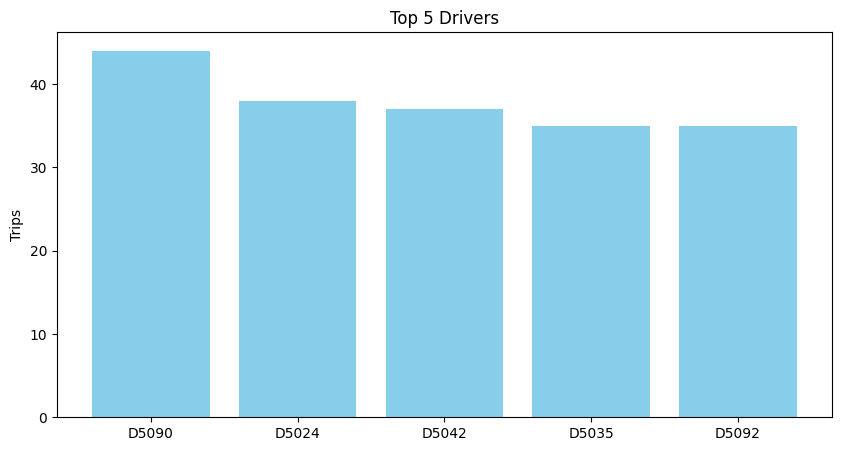

In [20]:
top_5_drivers = citygo_data['driver_id'].value_counts().nlargest(5)
print(f"📊 TOP 5 DRIVERS: {dict(top_5_drivers)}")

plt.figure(figsize=(10, 5))
plt.bar(range(len(top_5_drivers)), top_5_drivers.values, color='skyblue')
plt.xticks(range(len(top_5_drivers)), [f"D{id}" for id in top_5_drivers.index])
plt.ylabel('Trips')
plt.title('Top 5 Drivers')
plt.show()

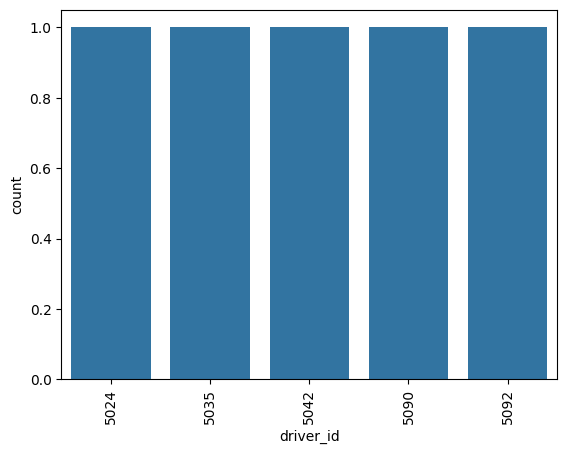

In [21]:
sns.countplot(top_5_drivers)
plt.xticks(rotation=90);

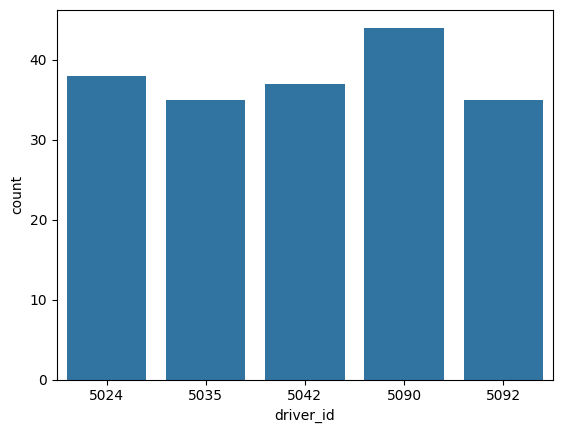

In [22]:
sns.barplot(top_5_drivers);


### Question 4: Which is the most popular vehicle_type on weekends?

In [23]:
citygo_data.head()

,trip_id,rider_id,driver_id,vehicle_type,trip_fare,day_type,rating,wait_time,trip_duration
0,100000,1352,5050,Shared,12.20,Weekday,4,12,48
1,100001,1012,5069,Shared,64.88,Weekend,5,8,37
2,100002,1338,5024,Economy,32.61,Weekday,2,9,69
3,100003,1327,5075,Economy,33.57,Weekday,Not given,18,24
4,100004,1064,5042,Economy,27.86,Weekend,5,20,49


In [24]:
weekends = citygo_data[citygo_data['day_type']=='Weekend']

In [25]:
weekends

,trip_id,rider_id,driver_id,vehicle_type,trip_fare,day_type,rating,wait_time,trip_duration
1,100001,1012,5069,Shared,64.88,Weekend,5,8,37
4,100004,1064,5042,Economy,27.86,Weekend,5,20,49
6,100006,1076,5072,Shared,56.72,Weekend,4,4,61
9,100009,1462,5053,Economy,60.92,Weekend,5,18,20
10,100010,1041,5082,Premium,63.29,Weekend,2,6,69
...,...,...,...,...,...,...,...,...,...
2484,102484,1383,5036,Shared,62.28,Weekend,3,6,17
2485,102485,1333,5010,Economy,7.21,Weekend,Not given,19,37
2493,102493,1334,5022,Economy,47.57,Weekend,Not given,19,66
2497,102497,1025,5066,Premium,16.82,Weekend,4,22,50


In [26]:
pop_vehicle_type = weekends['vehicle_type'].value_counts()
#pop_vehicle_type = weekends['vehicle_type'].value_counts().nlargest(1)
pop_vehicle_type

vehicle_type
Economy    391
Premium    135
Shared      95
SUV         80
Name: count, dtype: int64

Most popular on weekends: Economy (391 trips, 55.8%)


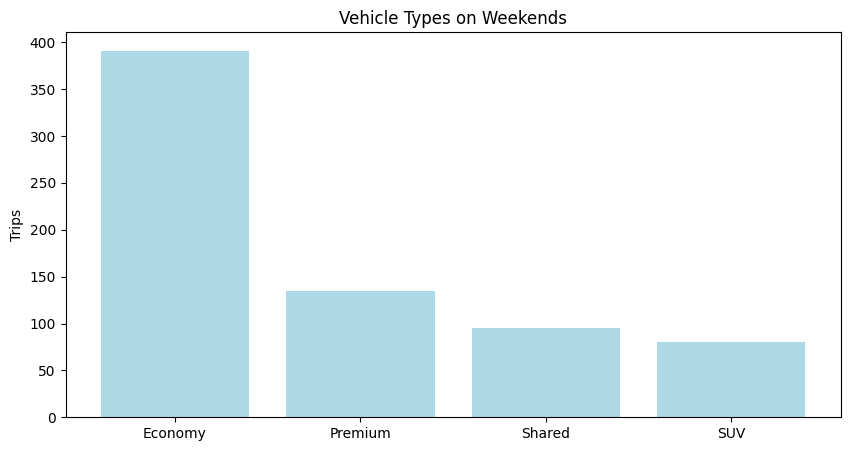

In [27]:
weekends = citygo_data[citygo_data['day_type'] == 'Weekend']
pop_vehicle = weekends['vehicle_type'].value_counts()
print(f"Most popular on weekends: {pop_vehicle.index[0]} ({pop_vehicle.values[0]} trips, {pop_vehicle.values[0]/len(weekends)*100:.1f}%)")

plt.figure(figsize=(10, 5))
plt.bar(pop_vehicle.index, pop_vehicle.values, color='lightblue')
plt.title('Vehicle Types on Weekends')
plt.ylabel('Trips')
plt.show()

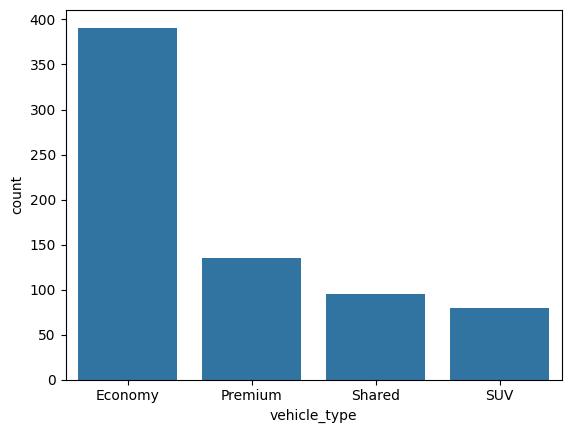

In [28]:
sns.barplot(pop_vehicle_type);

In [ ]:
#sns.histplot(count_per_vehicles,kde=True)
plt.title(' Most Popular Vehicle Type');

NameError: name 'count_per_vehicles' is not defined

In [ ]:
citygo_data.head()

,trip_id,rider_id,driver_id,vehicle_type,trip_fare,day_type,rating,wait_time,trip_duration
0,100000,1352,5050,Shared,12.20,Weekday,4,12,48
1,100001,1012,5069,Shared,64.88,Weekend,5,8,37
2,100002,1338,5024,Economy,32.61,Weekday,2,9,69
3,100003,1327,5075,Economy,33.57,Weekday,Not given,18,24
4,100004,1064,5042,Economy,27.86,Weekend,5,20,49


### Question 5: What percentage of the trips cost more than 25 dollars?

Percentage of trips > $25: 68.0%


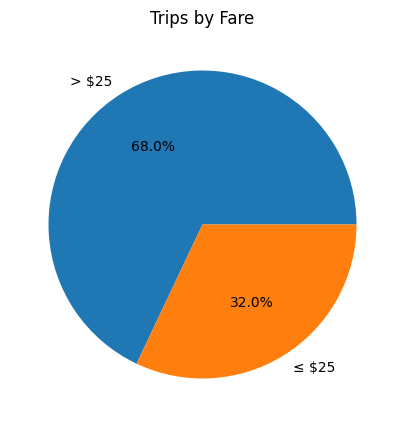

In [ ]:
trips_above_25 = (citygo_data['trip_fare'] > 25).sum()
percentage_above_25 = (trips_above_25 / len(citygo_data)) * 100
print(f"Percentage of trips > $25: {percentage_above_25:.1f}%")

plt.figure(figsize=(10, 5))
plt.pie([trips_above_25, len(citygo_data)-trips_above_25], labels=['> $25', '≤ $25'], autopct='%1.1f%%')
plt.title('Trips by Fare')
plt.show()

In [ ]:
#percentage_y = (citygo_data['trip_fare'] <= 25)

### Question 6: What is the mean trip duration?

In [ ]:
citygo_data.head()

,trip_id,rider_id,driver_id,vehicle_type,trip_fare,day_type,rating,wait_time,trip_duration
0,100000,1352,5050,Shared,12.20,Weekday,4,12,48
1,100001,1012,5069,Shared,64.88,Weekend,5,8,37
2,100002,1338,5024,Economy,32.61,Weekday,2,9,69
3,100003,1327,5075,Economy,33.57,Weekday,Not given,18,24
4,100004,1064,5042,Economy,27.86,Weekend,5,20,49


Mean trip duration: 41.5 minutes


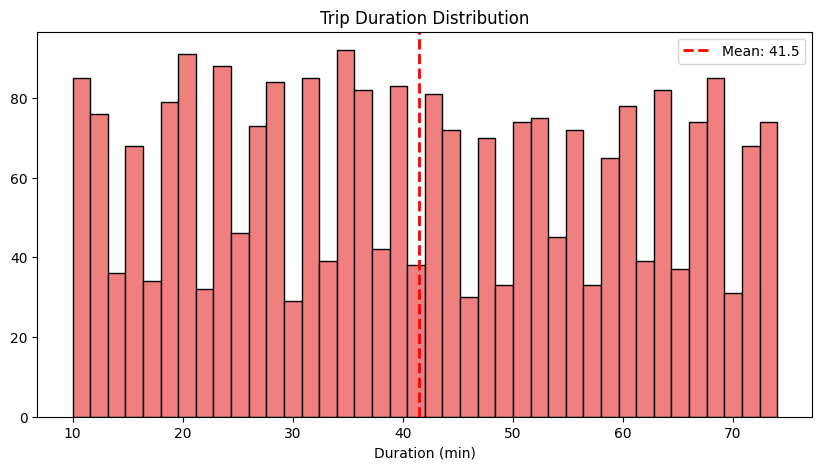

In [ ]:
mean_duration = citygo_data['trip_duration'].mean()
print(f"Mean trip duration: {mean_duration:.1f} minutes")

plt.figure(figsize=(10, 5))
plt.hist(citygo_data['trip_duration'], bins=40, color='lightcoral', edgecolor='black')
plt.axvline(mean_duration, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_duration:.1f}')
plt.xlabel('Duration (min)')
plt.title('Trip Duration Distribution')
plt.legend()
plt.show()

Top 3 Riders: {1344: np.int64(13), 1295: np.int64(12), 1064: np.int64(11)}
They account for 1.4% of all trips


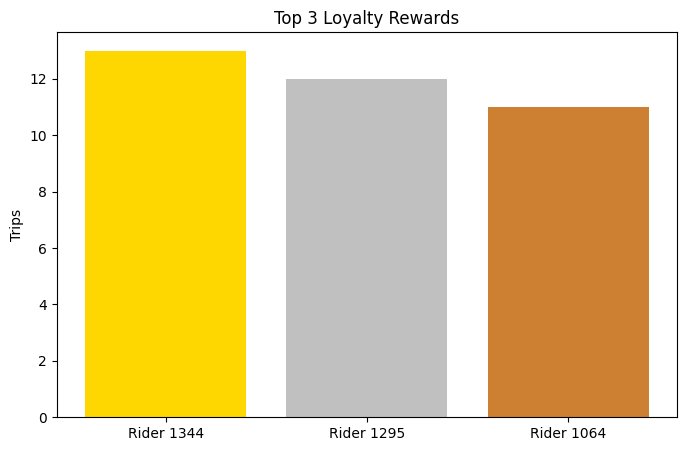

In [ ]:
top_3_riders = citygo_data['rider_id'].value_counts().nlargest(3)
print(f"Top 3 Riders: {dict(top_3_riders)}")
print(f"They account for {top_3_riders.sum()/len(citygo_data)*100:.1f}% of all trips")

plt.figure(figsize=(8, 5))
plt.bar(range(3), top_3_riders.values, color=['gold', 'silver', '#CD7F32'])
plt.xticks(range(3), [f"Rider {id}" for id in top_3_riders.index])
plt.ylabel('Trips')
plt.title('Top 3 Loyalty Rewards')
plt.show()

### Question 7: Top 3 Most Frequent Riders for Loyalty Rewards (20% Discount Vouchers)

In [ ]:
#top_3_cust1 = citygo_data['rider_id'].value_counts()
#top_3_cust1.head(3)


In [ ]:
### Question 8: Bivariate/Multivariate Analysis - Exploring Relationships Between Variables

In [ ]:
citygo_data.head()

,trip_id,rider_id,driver_id,vehicle_type,trip_fare,day_type,rating,wait_time,trip_duration
0,100000,1352,5050,Shared,12.20,Weekday,4,12,48
1,100001,1012,5069,Shared,64.88,Weekend,5,8,37
2,100002,1338,5024,Economy,32.61,Weekday,2,9,69
3,100003,1327,5075,Economy,33.57,Weekday,Not given,18,24
4,100004,1064,5042,Economy,27.86,Weekend,5,20,49


               trip_fare  wait_time  trip_duration
trip_fare       1.000000   0.001031       0.008974
wait_time       0.001031   1.000000      -0.033099
trip_duration   0.008974  -0.033099       1.000000


C:\Users\HP\AppData\Local\Temp\ipykernel_10444\1995017888.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([citygo_data[citygo_data['vehicle_type']==vt]['wait_time'].values


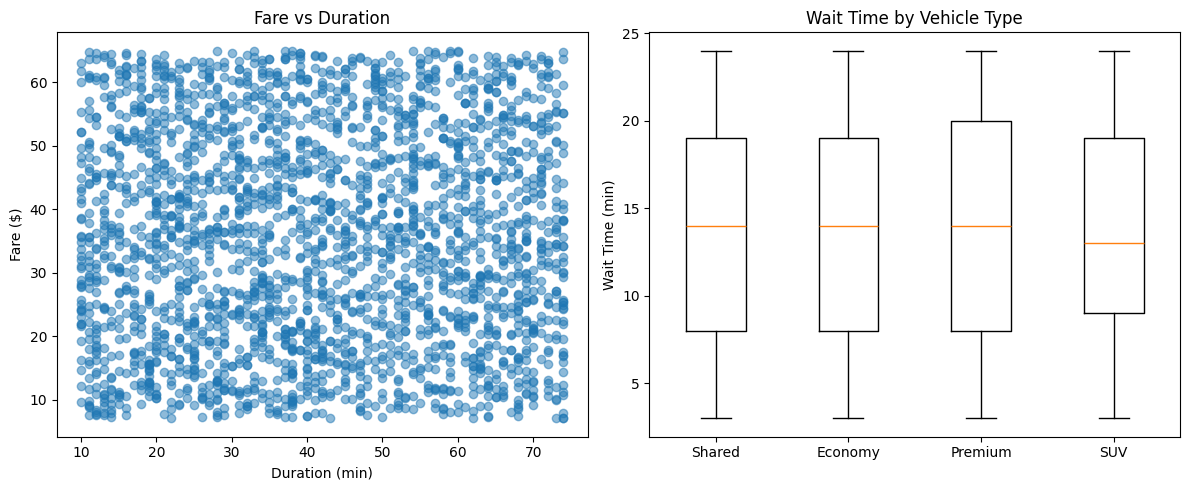

In [ ]:
# Correlation & Key Relationships
corr = citygo_data[['trip_fare', 'wait_time', 'trip_duration']].corr()
print(corr)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(citygo_data['trip_duration'], citygo_data['trip_fare'], alpha=0.5)
axes[0].set_xlabel('Duration (min)')
axes[0].set_ylabel('Fare ($)')
axes[0].set_title('Fare vs Duration')

axes[1].boxplot([citygo_data[citygo_data['vehicle_type']==vt]['wait_time'].values 
                  for vt in citygo_data['vehicle_type'].unique()],
               labels=citygo_data['vehicle_type'].unique())
axes[1].set_ylabel('Wait Time (min)')
axes[1].set_title('Wait Time by Vehicle Type')
plt.tight_layout()
plt.show()

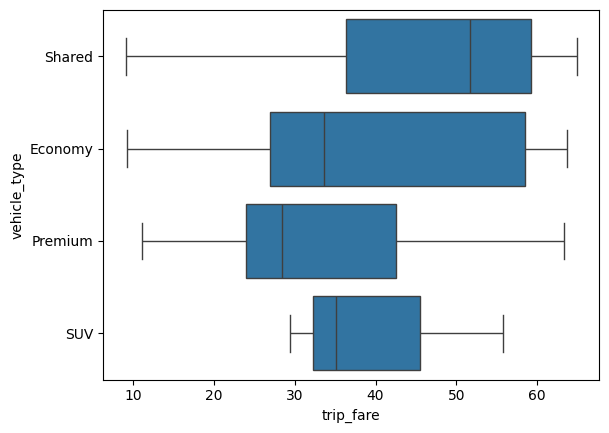

In [ ]:
#sns.scatterplot(citygo_data[['trip_fare','vehicle_type']],x="trip_fare",y="vehicle_type")
sns.boxplot(data=citygo_data.head(50),x='trip_fare', y='vehicle_type');

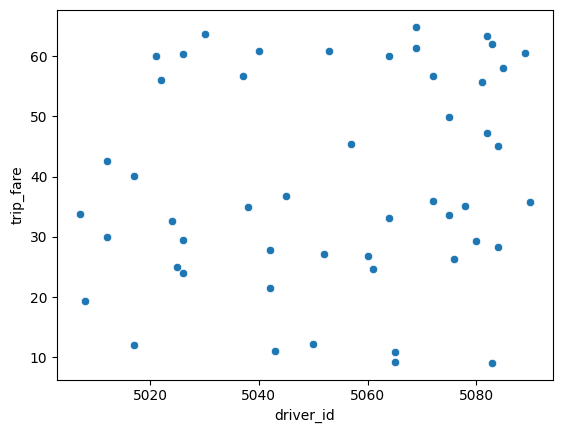

In [ ]:
sns.scatterplot(data=citygo_data.head(50),x='driver_id', y='trip_fare');

In [ ]:
### Question 9: Top Rated Drivers Bonus Program (Rating > 4.2, More than 15 trips)

,trip_id,rider_id,driver_id,vehicle_type,trip_fare,day_type,rating,wait_time,trip_duration
0,100000,1352,5050,Shared,12.20,Weekday,4,12,48
1,100001,1012,5069,Shared,64.88,Weekend,5,8,37
2,100002,1338,5024,Economy,32.61,Weekday,2,9,69
3,100003,1327,5075,Economy,33.57,Weekday,Not given,18,24
4,100004,1064,5042,Economy,27.86,Weekend,5,20,49


Top Rated Drivers (>4.2, >15 trips): 29 drivers
    driver_id  trips  avg_rating
1        5002     26    4.230769
2        5003     26    4.307692
3        5004     21    4.285714
7        5008     18    4.388889
16       5017     30    4.333333
17       5018     29    4.310345
18       5019     26    4.384615
21       5022     23    4.478261
26       5027     17    4.294118
30       5031     19    4.315789


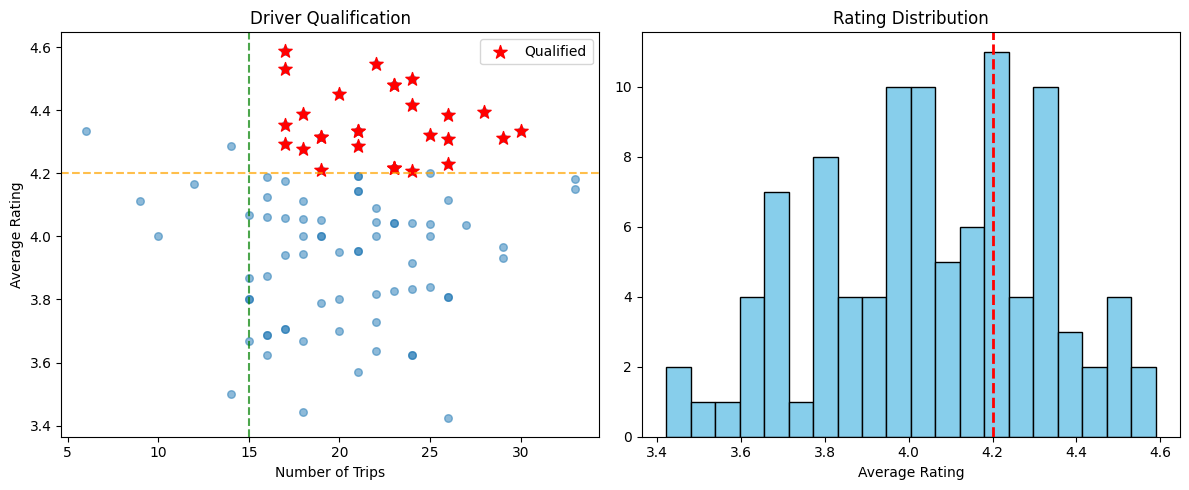

In [ ]:
# Top Rated Drivers (>4.2 rating, >15 trips)
rated = citygo_data[citygo_data['rating'] != 'Not given'].copy()
rated['rating_num'] = pd.to_numeric(rated['rating'], errors='coerce')
driver_stats = rated.groupby('driver_id')['rating_num'].agg(['count', 'mean']).reset_index()
driver_stats.columns = ['driver_id', 'trips', 'avg_rating']

top_drivers = driver_stats[(driver_stats['trips'] > 15) & (driver_stats['avg_rating'] > 4.2)]
print(f"Top Rated Drivers (>4.2, >15 trips): {len(top_drivers)} drivers")
print(top_drivers.head(10).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(driver_stats['trips'], driver_stats['avg_rating'], alpha=0.5, s=30)
axes[0].scatter(top_drivers['trips'], top_drivers['avg_rating'], color='red', s=100, marker='*', label='Qualified')
axes[0].axhline(4.2, color='orange', linestyle='--', alpha=0.7)
axes[0].axvline(15, color='green', linestyle='--', alpha=0.7)
axes[0].set_xlabel('Number of Trips')
axes[0].set_ylabel('Average Rating')
axes[0].set_title('Driver Qualification')
axes[0].legend()

axes[1].hist(driver_stats['avg_rating'], bins=20, color='skyblue', edgecolor='black')
axes[1].axvline(4.2, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Average Rating')
axes[1].set_title('Rating Distribution')
plt.tight_layout()
plt.show()

In [ ]:
#CityGo's revenue model: 25% commission on trips > $25, 15% commission on trips ≤ $25
# Calculate commission for each trip
commission_rate = []
for fare in citygo_data['trip_fare']:
    if fare > 25:
        commission_rate.append(0.25)
    else:
        commission_rate.append(0.15)

citygo_data['commission_rate'] = commission_rate
citygo_data['commission_revenue'] = citygo_data['trip_fare'] * citygo_data['commission_rate']

# Calculate total revenue
total_revenue = citygo_data['commission_revenue'].sum()
total_gross_fare = citygo_data['trip_fare'].sum()

# Break down by category
above_25 = citygo_data[citygo_data['trip_fare'] > 25]
below_equal_25 = citygo_data[citygo_data['trip_fare'] <= 25]

revenue_above_25 = above_25['commission_revenue'].sum()
revenue_below_equal_25 = below_equal_25['commission_revenue'].sum()

print("💰 CITYGO REVENUE MODEL ANALYSIS:")
print(f"\n📊 COMMISSION BREAKDOWN:")
print(f"Trips > $25 (25% commission):")
print(f"  - Number of trips: {len(above_25)}")
print(f"  - Gross fare: ${above_25['trip_fare'].sum():.2f}")
print(f"  - Commission revenue: ${revenue_above_25:.2f}")

print(f"\nTrips ≤ $25 (15% commission):")
print(f"  - Number of trips: {len(below_equal_25)}")
print(f"  - Gross fare: ${below_equal_25['trip_fare'].sum():.2f}")
print(f"  - Commission revenue: ${revenue_below_equal_25:.2f}")

print(f"\n✓ TOTAL NET REVENUE FOR CITYGO: ${total_revenue:,.2f}")
print(f"  - Total gross fare: ${total_gross_fare:,.2f}")
print(f"  - Effective commission rate: {(total_revenue/total_gross_fare)*100:.2f}%")

# Additional metrics
avg_commission = citygo_data['commission_rate'].mean()
print(f"  - Average commission rate: {avg_commission*100:.2f}%")

# Visualizations
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.3)

# 1. Revenue breakdown pie chart
ax1 = fig.add_subplot(gs[0, 0])
colors_revenue = ['#FF6B6B', '#4ECDC4']
ax1.pie([revenue_above_25, revenue_below_equal_25], 
        labels=['> $25 (25% Commission)', '≤ $25 (15% Commission)'],
        autopct='%1.1f%%',
        colors=colors_revenue,
        startangle=90,
        textprops={'fontsize': 11, 'weight': 'bold'})
ax1.set_title('Revenue Distribution by Fare Category', fontweight='bold', fontsize=12)

# 2. Revenue by category - bar chart
ax2 = fig.add_subplot(gs[0, 1])
categories = ['> $25\n(25% Commission)', '≤ $25\n(15% Commission)']
revenues = [revenue_above_25, revenue_below_equal_25]
bars = ax2.bar(categories, revenues, color=colors_revenue, edgecolor='black', linewidth=2)
ax2.set_ylabel('Revenue ($)')
ax2.set_title('CityGo Commission Revenue by Fare Category', fontweight='bold', fontsize=12)
ax2.grid(axis='y', alpha=0.3)
for bar, rev in zip(bars, revenues):
    ax2.text(bar.get_x() + bar.get_width()/2, rev, f'${rev:,.0f}', 
            ha='center', va='bottom', fontweight='bold', fontsize=11)

# 3. Scatter plot: Fare vs Commission
ax3 = fig.add_subplot(gs[1, 0])
scatter = ax3.scatter(citygo_data['trip_fare'], citygo_data['commission_revenue'], 
                      c=citygo_data['commission_rate']*100, cmap='RdYlGn', s=30, alpha=0.6)
ax3.axvline(25, color='red', linestyle='--', linewidth=2, label='$25 Threshold')
ax3.set_xlabel('Trip Fare ($)')
ax3.set_ylabel('Commission Revenue ($)')
ax3.set_title('Commission Revenue vs Trip Fare', fontweight='bold', fontsize=12)
ax3.legend()
ax3.grid(alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax3)
cbar.set_label('Commission Rate (%)')

# 4. Distribution of trip fares with revenue color
ax4 = fig.add_subplot(gs[1, 1])
bins = np.arange(0, citygo_data['trip_fare'].max() + 5, 5)
ax4.hist(below_equal_25['trip_fare'], bins=bins, alpha=0.7, color='#4ECDC4', label='≤ $25', edgecolor='black')
ax4.hist(above_25['trip_fare'], bins=bins, alpha=0.7, color='#FF6B6B', label='> $25', edgecolor='black')
ax4.axvline(25, color='black', linestyle='--', linewidth=2, label='Commission Threshold')
ax4.set_xlabel('Trip Fare ($)')
ax4.set_ylabel('Frequency')
ax4.set_title('Distribution of Trip Fares', fontweight='bold', fontsize=12)
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

# 5. Revenue trends by commission rate
ax5 = fig.add_subplot(gs[2, :])
fare_bins = np.arange(0, int(citygo_data['trip_fare'].max()) + 5, 5)
revenue_by_bin = []
bin_labels = []

for i in range(len(fare_bins)-1):
    bin_data = citygo_data[(citygo_data['trip_fare'] >= fare_bins[i]) & 
                           (citygo_data['trip_fare'] < fare_bins[i+1])]
    if len(bin_data) > 0:
        revenue_by_bin.append(bin_data['commission_revenue'].sum())
        bin_labels.append(f'${fare_bins[i]}-${fare_bins[i+1]}')
    else:
        revenue_by_bin.append(0)
        bin_labels.append(f'${fare_bins[i]}-${fare_bins[i+1]}')

colors_bars = ['#4ECDC4' if i < len(fare_bins)-1 and fare_bins[i] <= 25 else '#FF6B6B' 
               for i in range(len(fare_bins)-1)]
bars_revenue = ax5.bar(range(len(revenue_by_bin)), revenue_by_bin, color=colors_bars[:len(revenue_by_bin)], 
                       edgecolor='black', alpha=0.7)
ax5.set_xticks(range(len(bin_labels)))
ax5.set_xticklabels(bin_labels, rotation=45)
ax5.set_ylabel('Total Commission Revenue ($)')
ax5.set_xlabel('Fare Range ($)')
ax5.set_title('Commission Revenue by Fare Range', fontweight='bold', fontsize=12)
ax5.grid(axis='y', alpha=0.3)

# Add legend for colors
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#4ECDC4', label='15% Commission (≤ $25)'),
                   Patch(facecolor='#FF6B6B', label='25% Commission (> $25)')]
ax5.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.show()

print(f"\n💡 KEY INSIGHTS:")
print(f"- Premium trips (> $25) drive {(revenue_above_25/total_revenue)*100:.1f}% of total revenue")
print(f"- Lower-priced trips (≤ $25) drive {(revenue_below_equal_25/total_revenue)*100:.1f}% of total revenue")
print(f"- Average commission per trip: ${citygo_data['commission_revenue'].mean():.2f}")

### Question 10: CityGo Revenue Model - Commission Calculation (25% for >$25, 15% for ≤$25)